In [1]:
import sys
sys.path.append("..")

In [2]:
from SALib.sample import morris as morris_s
from SALib.analyze import morris as morris_a
import SALib
import numpy as np
import os
import sys
# # import PolarisOpt
# from PolarisOpt.utils import archiver
# from PolarisOpt.F import build_sampleset
from PolarisOpt.setup_manager import SetupManager
from PolarisOpt.utils import objective_funcs


/home/vsokolov/.conda/envs/pol/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Active Subspace dimension reduction technique is unavailable; Active Subspace package could not be loaded


In [3]:
import pickle
problem = pickle.load(open('../scratch/problem.pkl', 'rb'))


In [4]:
import pandas as pd
d = pd.read_csv("../scratch/aus-mc-hbw.csv")
p=problem['num_vars']
X = d.iloc[:,0:p].to_numpy()
Obj = d['m0'].to_numpy().astype(float)

In [5]:
Obj.dtype

dtype('float64')

In [6]:
Si = morris_a.analyze(problem, X, Obj, conf_level=0.95, num_levels=4)
Si['names']

['HBW_bCost_Generic',
 'HBW_bCost_drive_Parking',
 'HBW_bIVTT_drive',
 'HBW_bIVTT_getRide',
 'HBW_bIVTT_taxi',
 'HBW_bIVTT_AcEgT_XitWlk',
 'HBW_bInitWait_TransferTime_XitWlk',
 'HBW_bIVTT_AcEgT_XitDrv',
 'HBW_bInitWait_TransferTime_XitDrv',
 'HBW_bIVTT_OVTTAcEg_Rail',
 'HBW_bInitWait_TransferTime_Rail',
 'HBW_bIVTT_OVTTAcEg_RailDrv',
 'HBW_bInitWait_TransferTime_RailDrv',
 'HBW_bTotalTime_Rail',
 'HBW_bTotalTime_XitDrv']

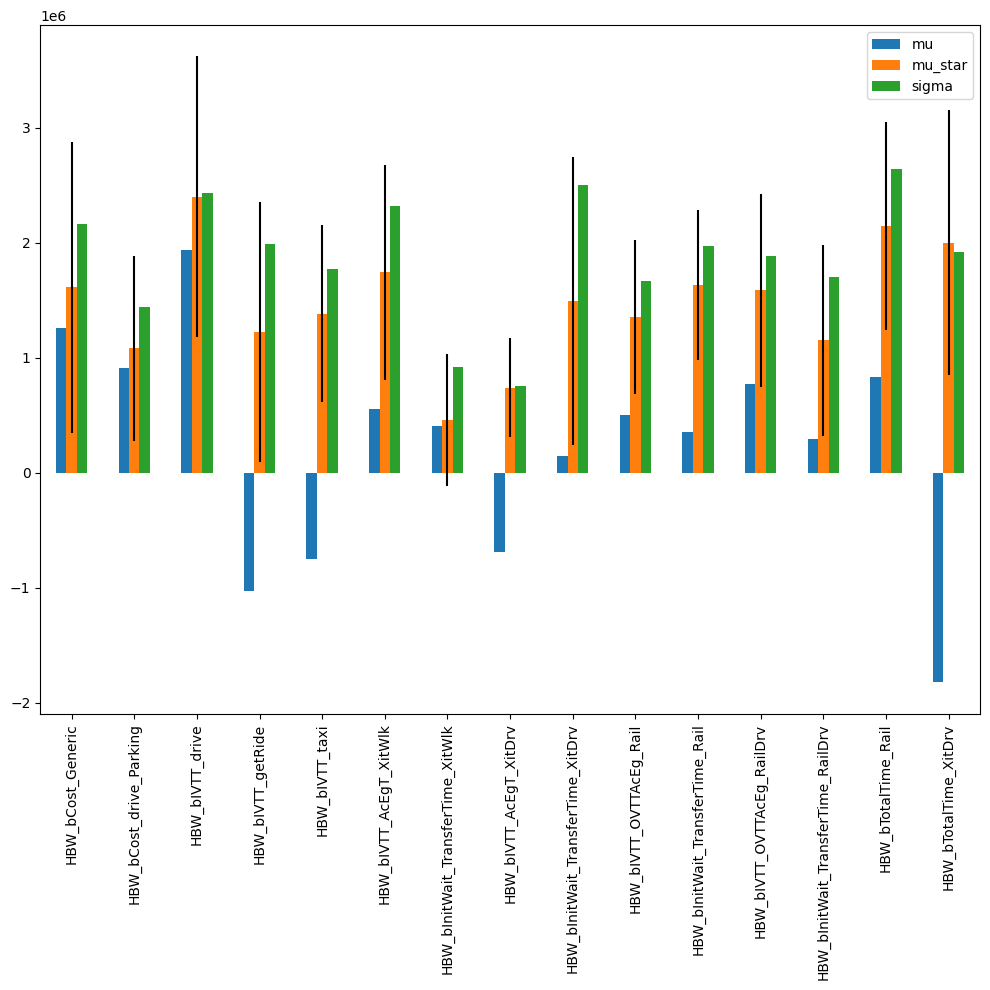

In [7]:
import matplotlib.pyplot as plt
axes = Si.plot()
fig = plt.gcf()  # get current figure
fig.set_size_inches(10, 10)
plt.tight_layout()

# plt.tight_layout()
# plt.show()


# fig, ax = plt.subplots(1, 1)
# SALib.plotting.morris.horizontal_bar_plot(ax, Si,{}, sortby='mu_star', unit=r"tCO$_2$/year")
# horizontal_bar_plot(ax, Si,{}, sortby='mu_star', unit=r"tCO$_2$/year")

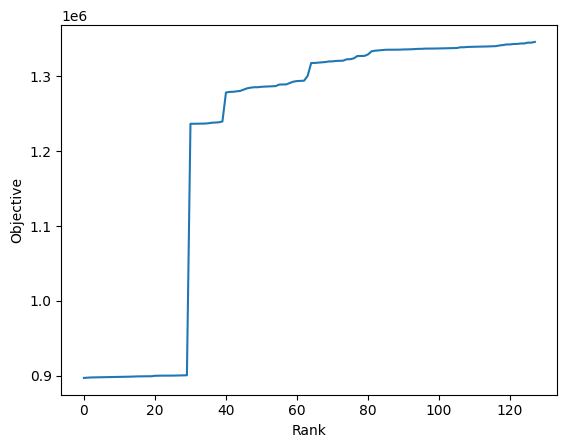

In [25]:
plt.plot(np.sort(Obj)); plt.xlabel('Rank'); plt.ylabel('Objective');

In [26]:
np.argmin(Obj)

26

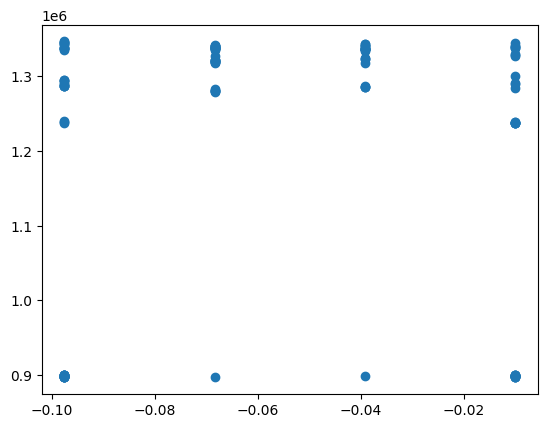

In [29]:
plt.scatter(X[:,14],Obj)

In [ ]:
 from sklearn.cross_decomposition import PLSRegression

In [ ]:
Y=Err
m = min(Y.shape[1],X.shape[1])
s = np.zeros(m-1) # sensitivity index
for i in range(1,m):
    pls = PLSRegression(n_components=i)
    pls.fit(X, Y)
    s[i-1] = pls.score(X, Y)

In [ ]:
plt.plot(s) 

In [ ]:
pls = PLSRegression(n_components=4)
pls.fit(X, Y);
pls.coef_.shape

In [ ]:
plt.bar(x=range(18),height=np.mean(np.abs(pls.coef_),axis=1))

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=114)
pca.fit(Y)

In [ ]:
plt.plot(pca.explained_variance_ratio_[0:10])

In [ ]:
plt.plot(np.arange(0,1440,2), np.mean(np.abs(Err),axis=0)); plt.xlabel('Time (min)'); plt.ylabel('Mean Error')